In [1]:
## plotting the new RELI analysis

library(data.table)
library(ggplot2)
library(ggrepel)

setwd("~/miniPCHiC/hILCs/RELI/")

library(readxl)

Warning message:
“replacing previous import ‘vctrs::data_frame’ by ‘tibble::data_frame’ when loading ‘dplyr’”


In [3]:
reli_2025 <- as.data.table(read_excel("Disease_RELI_results_min_10.xlsx"))
head(reli_2025[Phenotype == "Asthma"])
reli_2025_dcast <- as.data.table(dcast(reli_2025, Phenotype ~ ATAC_library, value.var = c("Enrichment", "Padj", "Total")))

Phenotype,ATAC_library,TF,Overlap,Total,Ratio,Mean,Std_Dev,Z_score,Enrichment,P_val,Padj,Null_Model,Species,-log10(Padj)
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
Asthma,CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_ATAC_hg19,none,25,120,0.20833300,11.24240,3.07729,4.470690,2.223730,3.89835e-06,0.001929683,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,2.714514
Asthma,CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19,none,25,120,0.20833300,11.31630,3.12992,4.371890,2.209190,6.15871e-06,0.003048561,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,2.515905
Asthma,ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19,none,18,120,0.15000000,7.63168,2.61185,3.969720,2.358590,3.59791e-05,0.017809655,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,1.749345
Asthma,ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_ATAC_hg19,none,13,120,0.10833300,6.36982,2.40794,2.753470,2.040880,2.94837e-03,1.000000000,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,0.000000
Asthma,ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_H3K4me3_hg19,none,7,120,0.05833330,3.14793,1.70033,2.265490,2.223690,1.17413e-02,1.000000000,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,0.000000
Asthma,CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_H3K27ac_hg19,none,1,120,0.00833333,1.11794,1.03927,-0.113484,0.894502,5.45177e-01,1.000000000,Null_Model_CommonSNP_OpenChrom_SNPmatch,human,0.000000


In [5]:
reli_2025_dcast_RE <- reli_2025_dcast[,c("Phenotype", 
                              "Enrichment_CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19",
                             "Enrichment_ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19",
                             "Padj_CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19", 
                             "Padj_ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19",
                             "Total_CD4_chicago_fres_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19", 
                             "Total_ILC3_chicago_fres_bin_5kb_abc_023_fres_extended_peakm_Jan25.txt_PIR_intersect_RE_hg19")]



In [6]:
colnames(reli_2025_dcast_RE) <- c("Phenotype", "enrichment_cd4_chic_abc", "enrichment_ilc_chic_abc", 
           "padj_cd4_chic_abc", "padj_ilc_chic_abc",
          "total_cd4_chic_abc", "total_ilc_chic_abc")

In [7]:
reli_2025_dcast_RE[,Phenotype := ifelse(Phenotype == "Chronic_inflammatory_diseases__ankylosing_spondylitis__Crohn_s_disease__psoriasis__primary_sclerosing_cholangitis__ulcerative_colitis___pleiotropy", "Chronic inflammatory diseases", Phenotype)]
reli_2025_dcast_RE[,Phenotype := ifelse(Phenotype == "Allergic_disease__asthma__hay_fever_or_eczema", "Allergic_disease", Phenotype)]


Warning message:
“Removed 22 rows containing missing values (geom_point).”
Warning message:
“Removed 22 rows containing missing values (geom_point).”


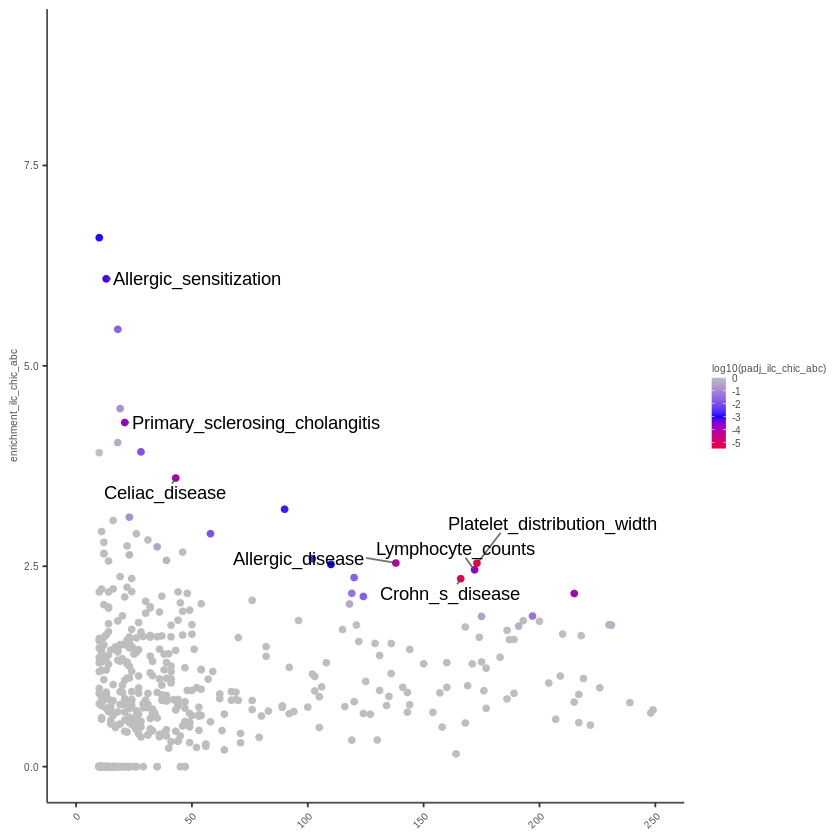

In [38]:
ggplot(reli_2025_dcast_RE, aes(x = total_ilc_chic_abc, y = enrichment_ilc_chic_abc, color = log10(padj_ilc_chic_abc))) +
geom_point() +
xlim(0,250) +
ylim(0,9) +
scale_color_gradient2(high = "grey",
  mid = "blue",
  low = "red",
  midpoint = -3,
  space = "Lab",
  guide = "colourbar",
  aesthetics = "colour") +
scale_size(range = c(1,15)) +
geom_text_repel(position=position_jitter(width=0.3), max.overlaps = Inf, segment.alpha = 0.8, 
                segment.color = "grey30", min.segment.length = 0, data = reli_2025_dcast_RE[padj_ilc_chic_abc < 1e-3][enrichment_ilc_chic_abc >= 2.2][total_ilc_chic_abc >=10],colour = "black", aes(label=Phenotype)) +
theme(axis.text.x = element_text(size = 6, angle = 45, vjust = 1, hjust=1),
        axis.title.x=element_blank(),
        axis.text.y = element_text(size = 6),
        axis.title.y = element_text(size = 6, colour = "grey30"),
        legend.title = element_text(size=6, colour = "grey30"),
        legend.text = element_text(size=6, colour = "grey30"),
        legend.key.width = unit(0.3, 'cm'),
        legend.key.height = unit(0.3, 'cm'),
        panel.background = element_rect(fill = "white"),
        axis.line.x=element_line(color="grey30"),
        axis.line.y=element_line(color="grey30")
        )

ggsave("reli_2025_ilc_chic_abc_0.023_enrich_vs_total_pval1e3_N10_enrich2.2_xlim250.pdf", device = "pdf", height = 5, width = 8, useDingbats=FALSE)


Warning message:
“Removed 22 rows containing missing values (geom_point).”
Warning message:
“Removed 22 rows containing missing values (geom_point).”


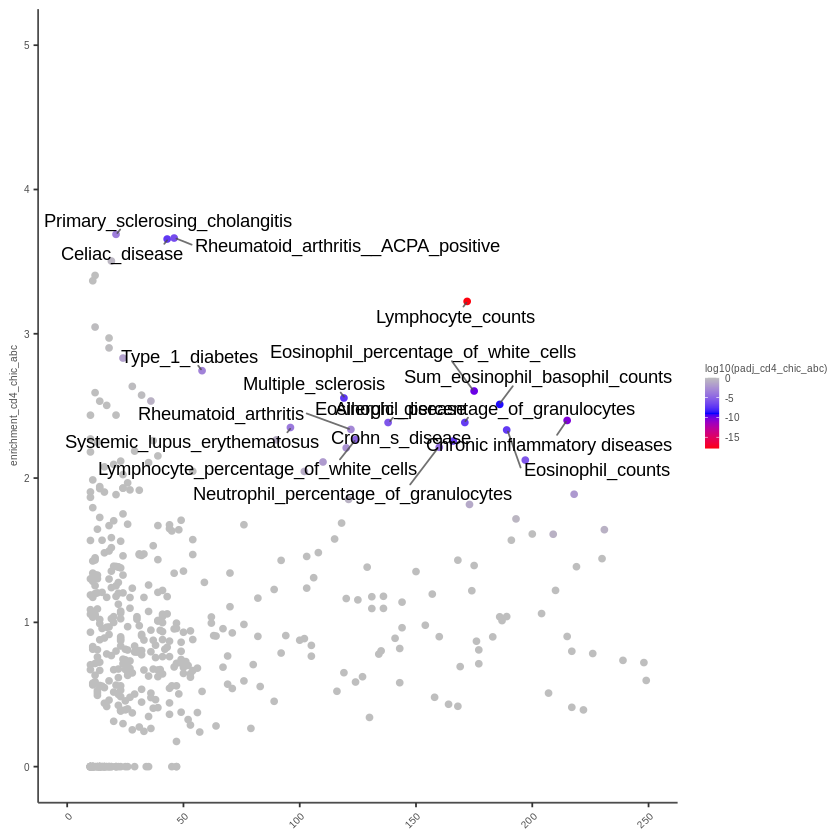

In [43]:
ggplot(reli_2025_dcast_RE, aes(x = total_cd4_chic_abc, y = enrichment_cd4_chic_abc, color = log10(padj_cd4_chic_abc))) +
geom_point() +
xlim(0,250) +
ylim(0,5) +
scale_color_gradient2(high = "grey",
  mid = "blue",
  low = "red",
  midpoint = -9,
  space = "Lab",
  guide = "colourbar",
  aesthetics = "colour") +
scale_size(range = c(1,15)) +
geom_text_repel(position=position_jitter(width=0.5), max.overlaps = 10000, segment.alpha = 0.8, 
                segment.color = "grey30", min.segment.length = 0, data = reli_2025_dcast_RE[padj_cd4_chic_abc < 1e-3][enrichment_cd4_chic_abc >= 2.2][total_cd4_chic_abc >=10],colour = "black", aes(label=Phenotype)) +
theme(axis.text.x = element_text(size = 6, angle = 45, vjust = 1, hjust=1),
        axis.title.x=element_blank(),
        axis.text.y = element_text(size = 6),
        axis.title.y = element_text(size = 6, colour = "grey30"),
        legend.title = element_text(size=6, colour = "grey30"),
        legend.text = element_text(size=6, colour = "grey30"),
        legend.key.width = unit(0.3, 'cm'),
        legend.key.height = unit(0.3, 'cm'),
        panel.background = element_rect(fill = "white"),
        axis.line.x=element_line(color="grey30"),
        axis.line.y=element_line(color="grey30")
      )

ggsave("reli_2025_cd4_chic_abc_0.023_enrich_vs_total_pval1e3_N10_enrich2.2_xlim250.pdf", device = "pdf", height = 5, width = 8, useDingbats=FALSE)
      

In [8]:
reli_2025_dcast_RE[Phenotype %in% c("Crohn_s_disease", "Multiple_sclerosis")]


Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Crohn_s_disease,2.25664,2.34409,1.191505e-07,6.955987e-06,166,166
Multiple_sclerosis,2.55490,2.16254,4.437170e-08,4.064836e-02,119,119


In [10]:
reli_2025_dcast_RE[padj_ilc_chic_abc < 0.05]

Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allergic_disease,2.38481,2.53974,1.709022e-06,6.710567e-05,138,138
Allergic_sensitization,1.64556,6.08577,1.000000e+00,7.153295e-04,13,13
Asthma,2.20919,2.35859,3.048561e-03,1.780965e-02,120,120
Asthma__childhood_onset,2.04591,2.59296,9.848817e-02,2.272976e-03,102,102
Celiac_disease,3.65665,3.60000,5.491827e-08,1.164507e-04,43,43
Chronic inflammatory diseases,2.39933,2.16029,3.875914e-11,1.188421e-04,215,215
Crohn_s_disease,2.25664,2.34409,1.191505e-07,6.955987e-06,166,166
IgA_nephropathy,2.18093,6.59852,1.000000e+00,1.168205e-03,10,10
IgG_glycosylation,1.67028,5.45603,1.000000e+00,1.974857e-02,18,18


Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


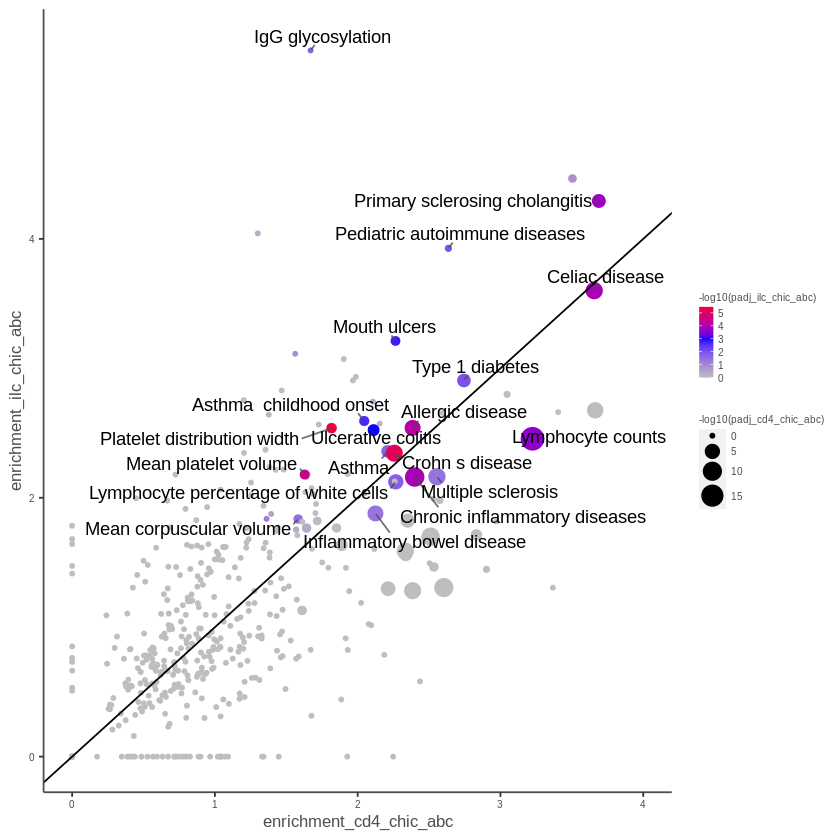

In [83]:
reli_2025_dcast_RE$Phenotype <- gsub("_", " ", reli_2025_dcast_RE$Phenotype)

ggplot(reli_2025_dcast_RE[total_ilc_chic_abc>10], aes(x = enrichment_cd4_chic_abc, y = enrichment_ilc_chic_abc, color = -log10(padj_ilc_chic_abc))) +
geom_point(aes(size = -log10(padj_cd4_chic_abc))) +
scale_color_gradient2(high = "red",
  mid = "blue",
  low = "grey",
  midpoint = 3,
  space = "Lab",
  guide = "colourbar",
  aesthetics = "colour") +
xlim(0,4) +
ylim(0,5.5) +
geom_abline(intercept = 0, slope = 1)+
# scale_size_continuous(range = c(1, 8),   # adjust visual min/max sizes
#                         breaks = c(10, 50, 100),
#                         name = "Total ILC (capped at 100)") +
# scale_size(range = c(1,10)) +
geom_text_repel(max.overlaps = Inf, segment.alpha = 0.8, 
                segment.color = "grey30", min.segment.length = 0, data = reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2][total_ilc_chic_abc>10],colour = "black", aes(label=Phenotype)) +
theme(axis.text.x = element_text(size = 6),
        axis.title.x=element_text(size = 10, colour = "grey30"),,
        axis.text.y = element_text(size = 6),
        axis.title.y = element_text(size = 10, colour = "grey30"),
        legend.title = element_text(size=6, colour = "grey30"),
        legend.text = element_text(size=6, colour = "grey30"),
        legend.key.width = unit(0.3, 'cm'),
        legend.key.height = unit(0.3, 'cm'),
        panel.background = element_rect(fill = "white"),
        axis.line.x=element_line(color="grey30"),
        axis.line.y=element_line(color="grey30")
        )

ggsave("reli_2025_ilc_vs_cd4_chic_abc_0.023_enrich_vs_enrich_pval5e2.pdf", device = "pdf", height = 8, width = 14, useDingbats=FALSE)


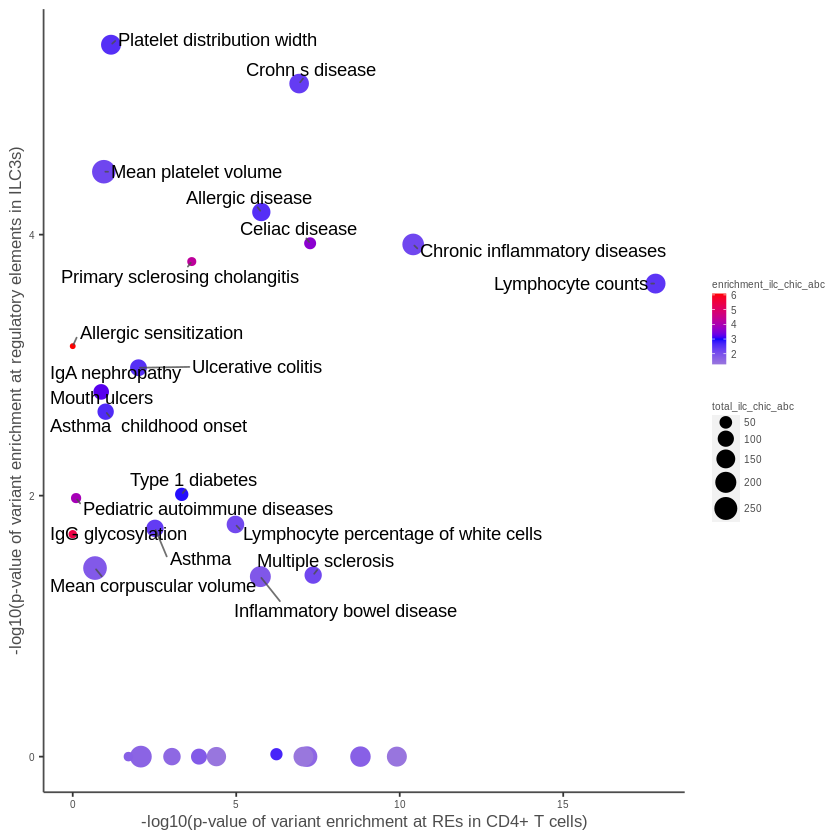

In [73]:
reli_2025_dcast_RE$Phenotype <- gsub("_", " ", reli_2025_dcast_RE$Phenotype)

ggplot(reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2 | padj_cd4_chic_abc < 5e-2][total_ilc_chic_abc>10], aes(x = -log10(padj_cd4_chic_abc), y = -log10(padj_ilc_chic_abc), color = enrichment_ilc_chic_abc)) +
geom_point(aes(size = total_ilc_chic_abc)) +
# scale_size(range = c(1, 16),
#            breaks = c(10, 50, 100),
#            name = "Total ILC")+
scale_color_gradient2(high = "red",
  mid = "blue",
  low = "grey",
  midpoint = 3,
  space = "Lab",
  guide = "colourbar",
  aesthetics = "colour") +
# scale_size_continuous(range = c(1, 15),   # adjust visual min/max sizes
#                         breaks = c(10, 50, 100),
#                         name = "Total ILC (capped at 100)") +
# scale_size("variant number per trait", range = c(1,15)) +
geom_text_repel(max.overlaps = Inf, segment.alpha = 0.8, 
                segment.color = "grey30", min.segment.length = 0, 
                data = reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2], 
                colour = "black", 
                aes(label=Phenotype)) +
xlab("-log10(p-value of variant enrichment at REs in CD4+ T cells)") + 
ylab("-log10(p-value of variant enrichment at regulatory elements in ILC3s)") + 
theme(axis.text.x = element_text(size = 6),
        axis.title.x=element_text(size = 10, colour = "grey30"),
        axis.text.y = element_text(size = 6),
        axis.title.y = element_text(size = 10, colour = "grey30"),
        legend.title = element_text(size=6, colour = "grey30"),
        legend.text = element_text(size=6, colour = "grey30"),
        legend.key.width = unit(0.3, 'cm'),
        legend.key.height = unit(0.3, 'cm'),
        panel.background = element_rect(fill = "white"),
        axis.line.x=element_line(color="grey30"),
        axis.line.y=element_line(color="grey30"),
#       legend.position = "bottom"
        )

# ggsave("reli_2025_ilc_vs_cd4_chic_abc_0.023_enrich_vs_total_ilc_pval5e2_N40_enrich_plot.pdf", device = "pdf", height = 6, width = 12, useDingbats=FALSE)
ggsave("reli_2025_ilc_vs_cd4_chic_abc_0.023_ilcpval_vs_cd4pval.pdf", device = "pdf", height = 10, width = 14, useDingbats=FALSE)


In [101]:
cor.test(reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2 & padj_cd4_chic_abc < 5e-2]$enrichment_cd4_chic_abc, reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2 & padj_cd4_chic_abc < 5e-2]$enrichment_ilc_chic_abc,
         method = "pearson")


	Pearson's product-moment correlation

data:  reli_2025_dcast_RE[padj_ilc_chic_abc < 0.05 & padj_cd4_chic_abc <  and reli_2025_dcast_RE[padj_ilc_chic_abc < 0.05 & padj_cd4_chic_abc <     0.05]$enrichment_cd4_chic_abc and     0.05]$enrichment_ilc_chic_abc
t = 5.0139, df = 10, p-value = 0.0005265
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5284303 0.9557734
sample estimates:
     cor 
0.845822 


In [13]:
cor.test(reli_2025_dcast_RE$enrichment_cd4_chic_abc, reli_2025_dcast_RE$enrichment_ilc_chic_abc,
         method = "pearson")


	Pearson's product-moment correlation

data:  reli_2025_dcast_RE$enrichment_cd4_chic_abc and reli_2025_dcast_RE$enrichment_ilc_chic_abc
t = 18.973, df = 493, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.5955943 0.6978081
sample estimates:
      cor 
0.6496272 


Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 3 rows containing missing values (geom_text_repel).”
Warning message:
“Removed 2 rows containing missing values (geom_point).”
Warning message:
“Removed 3 rows containing missing values (geom_text_repel).”


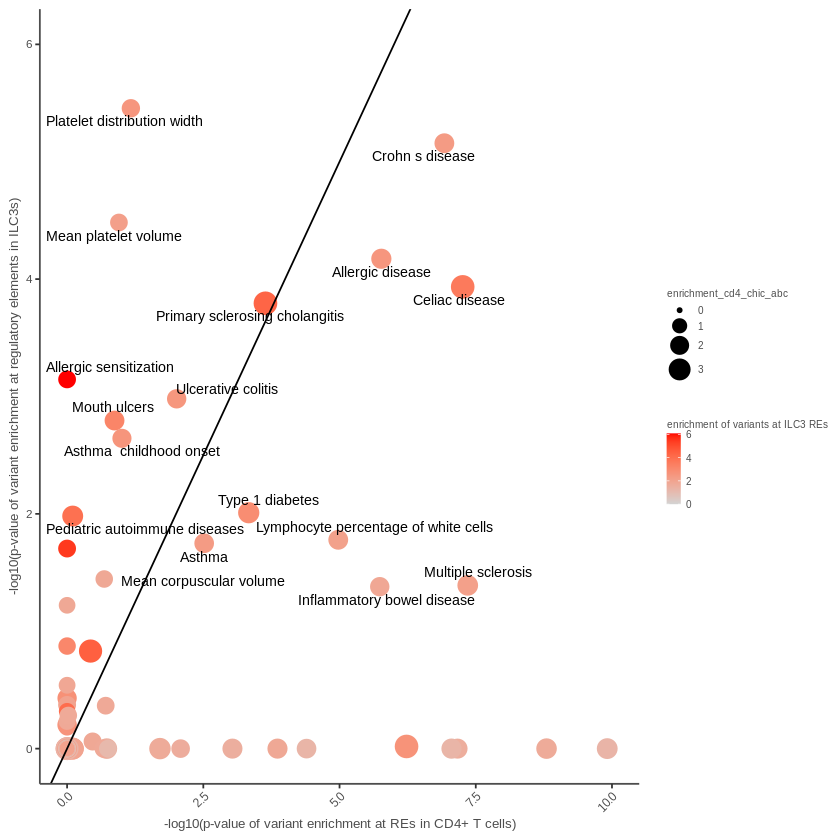

In [87]:
reli_2025_dcast_RE$Phenotype <- gsub("_", " ", reli_2025_dcast_RE$Phenotype)

ggplot(reli_2025_dcast_RE[total_ilc_chic_abc>10], aes(x = -log10(padj_cd4_chic_abc), y = -log10(padj_ilc_chic_abc), color = enrichment_ilc_chic_abc)) +
geom_point(aes(size = enrichment_cd4_chic_abc)) +
scale_color_gradient("enrichment of variants at ILC3 REs", high = "red", low = "lightgrey") +
xlim(0,10) +
ylim(0,6) +
geom_abline(intercept = 0, slope = 1) + 
# scale_size("variant number per trait", range = c(1,15)) +
geom_text_repel(size = 3, show.legend = FALSE, 
                position=position_jitter(width=0.2), 
                max.overlaps = Inf, segment.alpha = 0.8, 
                segment.color = "grey30", 
                data = reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2][total_ilc_chic_abc>10],
                colour = "black", 
                aes(label=Phenotype, size = 12)) +
xlab("-log10(p-value of variant enrichment at REs in CD4+ T cells)") + ylab("-log10(p-value of variant enrichment at regulatory elements in ILC3s)") + 
theme(axis.text.x = element_text(size = 7, angle = 45, vjust = 1, hjust=1),
        axis.title.x=element_text(size = 8, colour = "grey30"),,
        axis.text.y = element_text(size = 7),
        axis.title.y = element_text(size = 8, colour = "grey30"),
        legend.title = element_text(size=6, colour = "grey30"),
        legend.text = element_text(size=6, colour = "grey30"),
        legend.key.width = unit(0.3, 'cm'),
        legend.key.height = unit(0.3, 'cm'),
        legend.key = element_rect(fill = "white"),
        panel.background = element_rect(fill = "white"),
        axis.line.x=element_line(color="grey30"),
        axis.line.y=element_line(color="grey30")
        )

ggsave("reli_2025_ilc_vs_cd4_chic_abc_0.023_ilcpval_vs_cd4pval.pdf", device = "pdf", height = 7, width = 7, useDingbats=FALSE)


In [13]:
reli_dcast_RE[padj_ilc_chic_abc < 1e-3][enrichment_cd4_chic_abc >= 2][total_cd4_chic_abc >=40]$Phenotype

[1] "Allergic disease  asthma  hay fever or eczema"
 [2] "Asthma"                                       
 [3] "Asthma  childhood onset"                      
 [4] "Celiac disease"                               
 [5] "Chronic inflammatory diseases"                
 [6] "Crohn s disease"                              
 [7] "Inflammatory bowel disease"                   
 [8] "Lymphocyte counts"                            
 [9] "Lymphocyte percentage of white cells"         
[10] "Mouth ulcers"                                 
[11] "Multiple sclerosis"                           
[12] "Rheumatoid arthritis  ACPA positive"          
[13] "Type 1 diabetes"                              
[14] "Ulcerative colitis"

In [70]:
nrow(reli_dcast_RE[padj_ilc_chic_abc < 5e-2])
nrow(reli_2025_dcast_RE[padj_ilc_chic_abc < 5e-2])

nrow(reli_dcast_RE[padj_cd4_chic_abc < 5e-2])
nrow(reli_2025_dcast_RE[padj_cd4_chic_abc < 5e-2])



[1] 42

[1] 21

[1] 56

[1] 22

In [90]:
reli_dcast_RE[padj_ilc_chic_abc < 1e-2]
reli_2025_dcast_RE[padj_ilc_chic_abc < 1e-2]

reli_dcast_RE[padj_cd4_chic_abc < 1e-2]
reli_2025_dcast_RE[padj_cd4_chic_abc < 1e-2]


Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allergic disease,2.38481,2.53974,1.709022e-06,6.710567e-05,138,138
Allergic sensitization,1.64556,6.08577,1.000000e+00,7.153295e-04,13,13
Asthma childhood onset,2.04591,2.59296,9.848817e-02,2.272976e-03,102,102
Celiac disease,3.65665,3.60000,5.491827e-08,1.164507e-04,43,43
Chronic inflammatory diseases,2.39933,2.16029,3.875914e-11,1.188421e-04,215,215
Crohn s disease,2.25664,2.34409,1.191505e-07,6.955987e-06,166,166
IgA nephropathy,2.18093,6.59852,1.000000e+00,1.168205e-03,10,10
Lymphocyte counts,3.22434,2.45558,1.499900e-18,2.371441e-04,172,172
Mean platelet volume,1.62885,2.17928,1.118512e-01,3.293507e-05,267,267


Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allergic disease,2.37914,2.73088,6.211466e-07,1.150398e-06,138,138
Allergic rhinitis,1.83899,2.76267,1.620123e-01,5.091804e-03,44,44
Allergic sensitization,2.46025,6.18356,3.126011e-01,4.249147e-05,13,13
Allergy,1.53947,3.12726,6.988170e-01,7.505261e-03,23,23
Asthma,2.17528,2.29897,2.525139e-04,1.615469e-03,120,120
Asthma adult onset,2.38809,2.84457,7.498856e-03,5.123791e-03,39,39
Asthma childhood onset,2.26020,2.61871,2.096585e-04,3.453643e-04,102,102
Celiac disease,3.69529,3.92353,5.335829e-09,1.150398e-06,43,43
Chronic inflammatory diseases,2.45855,2.13836,1.307937e-12,4.249147e-05,215,215


Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Allergic disease,2.38481,2.53974,1.709022e-06,6.710567e-05,138,138
Asthma,2.20919,2.35859,3.048561e-03,1.780965e-02,120,120
Celiac disease,3.65665,3.60000,5.491827e-08,1.164507e-04,43,43
Chronic inflammatory diseases,2.39933,2.16029,3.875914e-11,1.188421e-04,215,215
Crohn s disease,2.25664,2.34409,1.191505e-07,6.955987e-06,166,166
Eosinophil counts,2.33337,1.58728,6.832534e-08,1.000000e+00,189,189
Eosinophil percentage of granulocytes,2.38498,1.28211,8.816148e-08,1.000000e+00,171,171
Eosinophil percentage of white cells,2.60331,1.30619,1.222586e-10,1.000000e+00,175,175
Inflammatory bowel disease,2.12449,1.87887,1.828317e-06,4.173543e-02,197,197


Phenotype,enrichment_cd4_chic_abc,enrichment_ilc_chic_abc,padj_cd4_chic_abc,padj_ilc_chic_abc,total_cd4_chic_abc,total_ilc_chic_abc
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Acute lymphoblastic leukemia B cell precursor,8.30290,4.49663,7.491020e-05,3.956219e-01,5,5
Allergic disease,2.37914,2.73088,6.211466e-07,1.150398e-06,138,138
Asthma,2.17528,2.29897,2.525139e-04,1.615469e-03,120,120
Asthma adult onset,2.38809,2.84457,7.498856e-03,5.123791e-03,39,39
Asthma childhood onset,2.26020,2.61871,2.096585e-04,3.453643e-04,102,102
Celiac disease,3.69529,3.92353,5.335829e-09,1.150398e-06,43,43
Chronic inflammatory diseases,2.45855,2.13836,1.307937e-12,4.249147e-05,215,215
Crohn s disease,2.33693,2.54607,1.211720e-09,1.361802e-07,166,166
Eosinophil counts,2.50322,1.66763,1.721313e-11,8.286990e-02,189,189
